# Synfuel reactor — exploratory data analysis

Phase 2 of the closed-loop synfuel-reactor project. We take the first-principles
reactor from Phase 1, sweep its input space with a Latin-hypercube design of
experiments, and explore what the data says about **yield, selectivity, and thermal
runaway**.

Inputs swept (see `analysis/sample.py`): feed `H2:CO2` ratio, pressure, coolant
temperature, catalyst loading, and jacket cooling capacity `UA`.

Generate the dataset first if needed: `uv run python -m analysis.sample --n 512`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from analysis.eda import load
from analysis import sensitivity, noise
from analysis.sample import INPUT_NAMES

df = load()
print(f'{len(df)} samples, runaway fraction = {df.runaway.mean():.1%}')
df.describe().round(3)

512 samples, runaway fraction = 58.6%


,h2_co2_ratio,pressure_bar,coolant_temp,catalyst,cooling_ua,T_final_C,T_max_C,co2_conversion,c5plus_yield,runaway
count,512.000,512.000,512.000,512.000,512.000,512.000,512.000,512.000,512.000,512.000
mean,3.000,25.001,505.000,1.750,42499.020,262.024,315.456,0.544,0.491,0.586
std,0.578,5.780,20.224,0.722,21670.090,35.980,57.732,0.191,0.181,0.493
min,2.003,15.008,470.130,0.503,5112.787,202.571,205.145,0.146,0.106,0.000
25%,2.501,19.996,487.554,1.128,23735.666,234.898,266.386,0.384,0.341,0.000
50%,3.000,24.992,504.989,1.749,42507.212,258.781,322.174,0.550,0.499,1.000
75%,3.499,29.990,522.483,2.375,61200.320,280.924,359.637,0.673,0.614,1.000
max,3.998,34.993,539.865,3.000,79870.643,407.952,446.528,0.981,0.900,1.000


## 1. The runaway boundary

Thermal runaway is driven by the balance of heat generation (set by pressure /
reactant concentration and catalyst) against heat removal (cooling `UA`). Plotting the
two strongest drivers shows a clear safe / unsafe boundary.

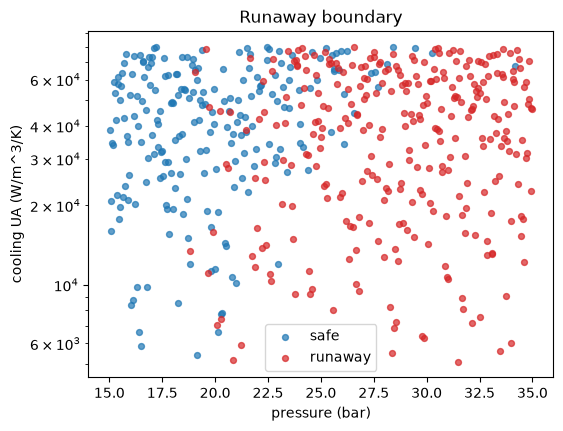

In [2]:
safe, ra = df[df.runaway == 0], df[df.runaway == 1]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(safe.pressure_bar, safe.cooling_ua, c='tab:blue', s=18, alpha=0.7, label='safe')
ax.scatter(ra.pressure_bar, ra.cooling_ua, c='tab:red', s=18, alpha=0.7, label='runaway')
ax.set(yscale='log', xlabel='pressure (bar)', ylabel='cooling UA (W/m^3/K)',
       title='Runaway boundary')
ax.legend(); plt.show()

## 2. The conversion / selectivity trade-off

C5+ yield = conversion x C5+ selectivity. Hotter conditions raise conversion but the
Anderson-Schulz-Flory distribution sets how much of that carbon ends up as valuable
C5+ liquid. The colour shows peak temperature climbing along the trade-off.

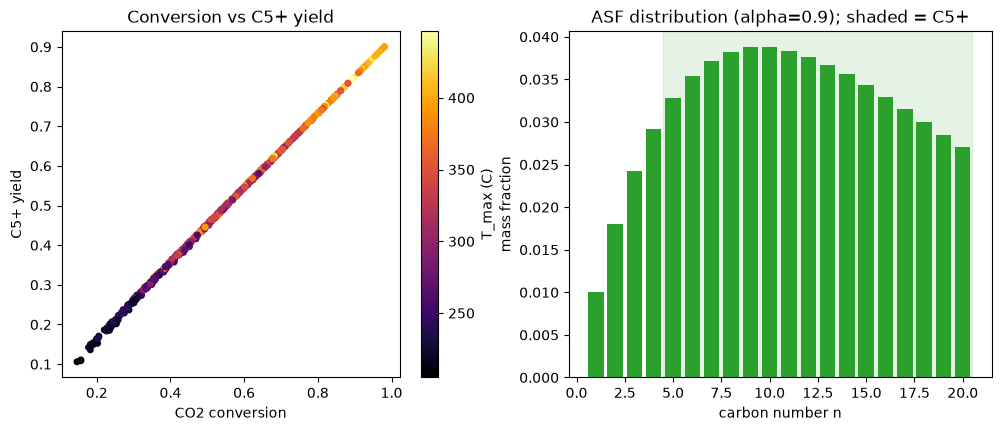

In [3]:
from sim.reactor import asf_weight_fraction
from sim import params as P

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.5))
sc = a0.scatter(df.co2_conversion, df.c5plus_yield, c=df.T_max_C, cmap='inferno', s=16)
a0.set(xlabel='CO2 conversion', ylabel='C5+ yield', title='Conversion vs C5+ yield')
fig.colorbar(sc, ax=a0, label='T_max (C)')

n = np.arange(1, 21)
a1.bar(n, asf_weight_fraction(n, P.ASF_ALPHA), color='tab:green')
a1.axvspan(4.5, 20.5, color='tab:green', alpha=0.12)
a1.set(xlabel='carbon number n', ylabel='mass fraction',
       title=f'ASF distribution (alpha={P.ASF_ALPHA}); shaded = C5+')
plt.show()

## 3. Global sensitivity (Sobol)

Which inputs actually drive each output? Variance-based Sobol indices, estimated with
a from-scratch Saltelli scheme (`analysis/sensitivity.py`). `S1` is the first-order
effect; `ST` is the total effect including interactions. A small `n` is used here for
speed — bump it up for publication-quality estimates.

  c5plus_yield: dominant driver = pressure_bar (ST=0.41)
       T_max_C: dominant driver = pressure_bar (ST=0.77)
       runaway: dominant driver = pressure_bar (ST=0.88)


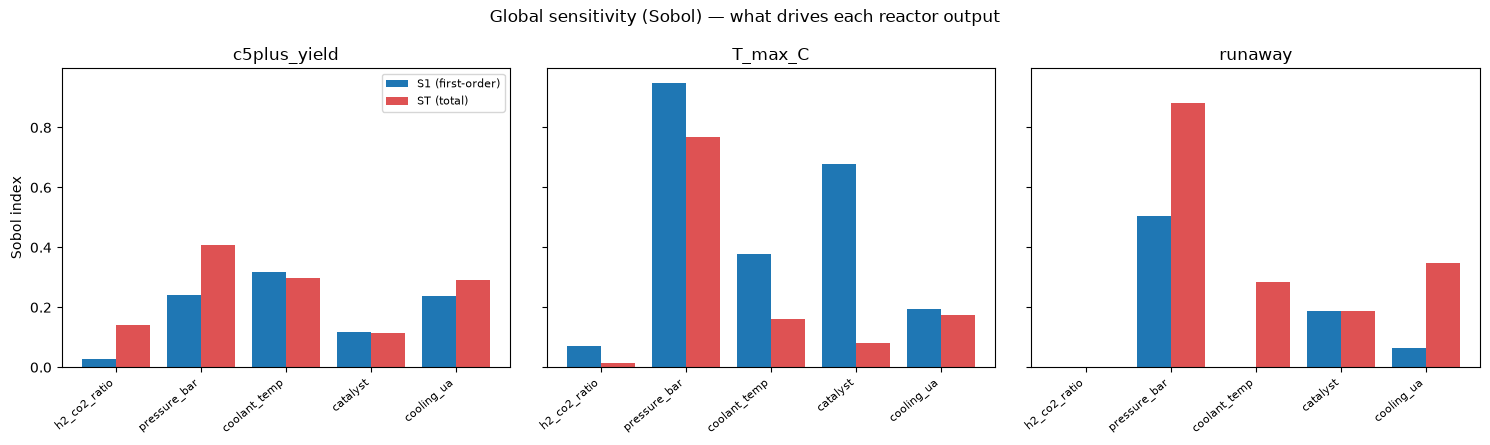

In [4]:
results = sensitivity.analyze(n=64)
for out in sensitivity.OUTPUTS:
    order = np.argsort(results[out]['ST'])[::-1]
    top = INPUT_NAMES[order[0]]
    print(f"{out:>14}: dominant driver = {top} (ST={results[out]['ST'][order[0]]:.2f})")
sensitivity.plot(results, show=True);

## 4. Sensor + ADC noise

Real telemetry is not clean. The `analysis/noise.py` model adds analog sensor noise
and 12-bit ESP32 ADC quantisation — the same model the Phase 6 firmware reuses. The
sensor noise dominates the ADC quantisation, so the channel is sensor-limited.

temperature: quant=0.061C  RMS=1.494C  ENOB=5.6 bits
   pressure: quant=0.012bar  RMS=0.202bar  ENOB=6.2 bits


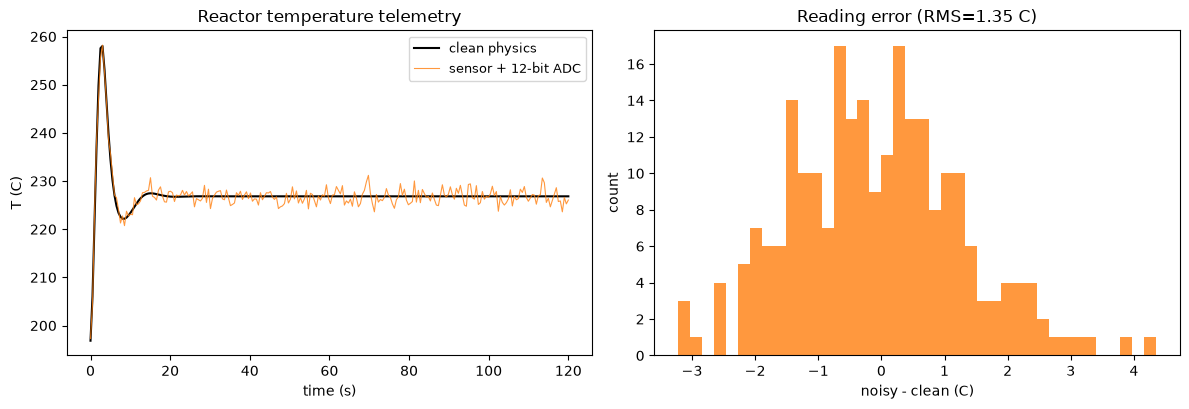

In [5]:
rng = np.random.default_rng(0)
for ch in (noise.TEMPERATURE, noise.PRESSURE):
    c = noise.characterize(ch, rng)
    print(f"{c['channel']:>11}: quant={c['quantization_step']:.3f}{ch.unit}  "
          f"RMS={c['rms_error']:.3f}{ch.unit}  ENOB={c['enob']:.1f} bits")
noise.demo(show=True);